### Theory

# 🧠 Natural Language Processing (NLP) Overview

---

## 📄 Document Representation in NLP

- **Bag of Words (BoW)**:
  - A document is represented as a vector of word counts.
  - Ignores grammar and word order—just focuses on **word frequency**.

- **Cosine Similarity**:
  - Measures similarity between two document vectors based on the angle between them.
  - Ranges from 0 (not similar) to 1 (very similar).

---

## 🔍 TF-IDF: Improving Bag of Words

- **TF-IDF (Term Frequency – Inverse Document Frequency)**:
  - Highlights important words in a document relative to the entire corpus.
  - Formula:  
    `TF-IDF(t, d) = TF(t, d) × IDF(t)`

### Term Frequency (TF)
- Measures how often a term appears in a document.
- Formula:  
  `TF(t, d) = Number of times term t appears in document d`

### Inverse Document Frequency (IDF)
- Measures how unique or rare a term is across all documents.
- Formula:  
  `IDF(t) = log(D / dₜ)`  
  where:
  - `D` = Total number of documents  
  - `dₜ` = Number of documents containing the term `t`

- Common words (e.g., "the", "and") get **lower scores**; rare words get **higher scores**.

---

## 💡 Additional Good-to-Know NLP Concepts

- **Tokenization**:
  - Splits text into smaller units like words or sentences.

- **Stop Words**:
  - Common words (e.g., "the", "is", "and") usually removed to reduce noise.

- **Stemming and Lemmatization**:
  - **Stemming**: Chops off word endings (e.g., "running" → "run").
  - **Lemmatization**: Reduces words to their base form considering grammar (e.g., "better" → "good").

- **N-grams**:
  - Sequences of `n` words (e.g., bigrams = 2-word sequences like "New York").
  - Helps capture **word order** and **context**.

- **Word Embeddings (e.g., Word2Vec, GloVe)**:
  - Represents words as dense vectors in a high-dimensional space.
  - Similar words are located closer together in vector space.

- **Named Entity Recognition (NER)**:
  - Identifies and classifies named entities in text (e.g., people, organizations, locations).

- **Part-of-Speech Tagging (POS)**:
  - Labels each word in a sentence with its grammatical role (noun, verb, adjective, etc.).

- **Sentiment Analysis**:
  - Detects the sentiment (positive, negative, neutral) expressed in text.

---

## ✅ Summary

- Use **BoW** and **TF-IDF** to convert text into numeric features.
- **TF-IDF** improves upon BoW by lowering the weight of frequent/common terms.
- Other core tasks like **tokenization**, **POS tagging**, and **NER** help extract structured information from raw text.
- Advanced techniques like **word embeddings** and **transformers** go beyond word counts and provide richer context understanding.



### Model Building

In [1]:
import nltk

In [2]:
msg = [line.rstrip() for line in open('smsspamcollection/SMSSpamCollection')]

In [3]:
len(msg)

5574

In [4]:
msg[0]

'ham\tGo until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...'

In [5]:
for mess_no, message in enumerate(msg[:10]):
    print(mess_no, message)
    print("\n")

0 ham	Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...


1 ham	Ok lar... Joking wif u oni...


2 spam	Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std txt rate)T&C's apply 08452810075over18's


3 ham	U dun say so early hor... U c already then say...


4 ham	Nah I don't think he goes to usf, he lives around here though


5 spam	FreeMsg Hey there darling it's been 3 week's now and no word back! I'd like some fun you up for it still? Tb ok! XxX std chgs to send, Â£1.50 to rcv


6 ham	Even my brother is not like to speak with me. They treat me like aids patent.


7 ham	As per your request 'Melle Melle (Oru Minnaminunginte Nurungu Vettam)' has been set as your callertune for all Callers. Press *9 to copy your friends Callertune


8 spam	WINNER!! As a valued network customer you have been selected to receivea Â£900 prize reward! To claim call 09061701461. Claim cod

In [6]:
import pandas as pd
msgs = pd.read_csv("smsspamcollection/SMSSpamCollection", sep="\t", names=['label', 'message'])

In [7]:
msgs

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...
5568,ham,Will ü b going to esplanade fr home?
5569,ham,"Pity, * was in mood for that. So...any other s..."
5570,ham,The guy did some bitching but I acted like i'd...


In [8]:
msgs.describe()

,label,message
count,5572,5572
unique,2,5169
top,ham,"Sorry, I'll call later"
freq,4825,30


In [9]:
msgs.groupby('label').describe()

message                                                               
        count unique                                                top freq
label                                                                       
ham      4825   4516                             Sorry, I'll call later   30
spam      747    653  Please call our customer service representativ...    4

In [10]:
#A Large part of NLP is domain knowledge
msgs['length'] = msgs['message'].apply(len)
msgs

,label,message,length
0,ham,"Go until jurong point, crazy.. Available only ...",111
1,ham,Ok lar... Joking wif u oni...,29
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,ham,U dun say so early hor... U c already then say...,49
4,ham,"Nah I don't think he goes to usf, he lives aro...",61
...,...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...,160
5568,ham,Will ü b going to esplanade fr home?,36
5569,ham,"Pity, * was in mood for that. So...any other s...",57
5570,ham,The guy did some bitching but I acted like i'd...,125


In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

<Axes: xlabel='length', ylabel='Count'>

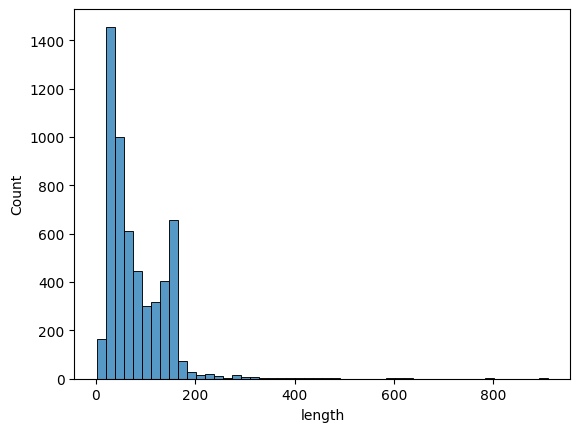

In [12]:
sns.histplot(msgs, x='length', bins=50)

<Axes: xlabel='length', ylabel='Count'>

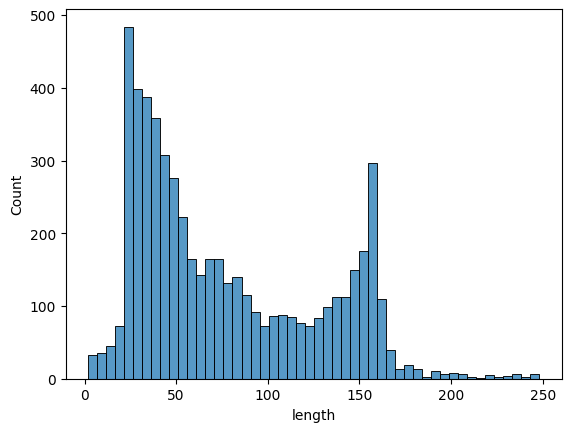

In [13]:
#Showing the majority distribution, excluding outliers
sns.histplot(msgs[msgs['length'] < 250], x='length', bins=50)

In [14]:
msgs['length'].describe()

count    5572.000000
mean       80.489950
std        59.942907
min         2.000000
25%        36.000000
50%        62.000000
75%       122.000000
max       910.000000
Name: length, dtype: float64

array([<Axes: title={'center': 'ham'}>, <Axes: title={'center': 'spam'}>],
      dtype=object)

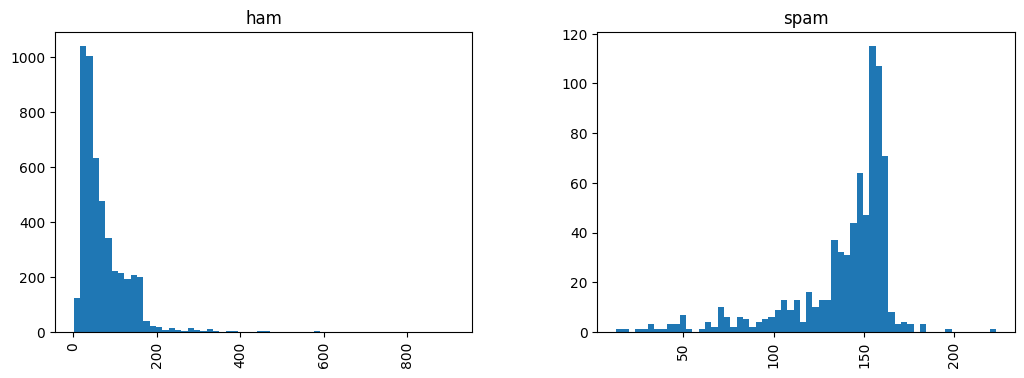

In [15]:
#Length appears to be a good way to distinguish between ham vs spam
msgs.hist(column='length', by='label', bins=60, figsize=(12,4))

In [16]:
#Converting a sequence of characters into numbers
import string

# Remove punctuation from each message in the 'message' column
# msgs['message'] = msgs['message'].apply(lambda x: ''.join([c for c in x if c not in string.punctuation]))
# msgs

In [17]:
#A list of words that don't give us any distinguishing features (very common words that are not too helpful)
from nltk.corpus import stopwords
stopwords.words('english')

['a',
 'about',
 'above',
 'after',
 'again',
 'against',
 'ain',
 'all',
 'am',
 'an',
 'and',
 'any',
 'are',
 'aren',
 "aren't",
 'as',
 'at',
 'be',
 'because',
 'been',
 'before',
 'being',
 'below',
 'between',
 'both',
 'but',
 'by',
 'can',
 'couldn',
 "couldn't",
 'd',
 'did',
 'didn',
 "didn't",
 'do',
 'does',
 'doesn',
 "doesn't",
 'doing',
 'don',
 "don't",
 'down',
 'during',
 'each',
 'few',
 'for',
 'from',
 'further',
 'had',
 'hadn',
 "hadn't",
 'has',
 'hasn',
 "hasn't",
 'have',
 'haven',
 "haven't",
 'having',
 'he',
 "he'd",
 "he'll",
 'her',
 'here',
 'hers',
 'herself',
 "he's",
 'him',
 'himself',
 'his',
 'how',
 'i',
 "i'd",
 'if',
 "i'll",
 "i'm",
 'in',
 'into',
 'is',
 'isn',
 "isn't",
 'it',
 "it'd",
 "it'll",
 "it's",
 'its',
 'itself',
 "i've",
 'just',
 'll',
 'm',
 'ma',
 'me',
 'mightn',
 "mightn't",
 'more',
 'most',
 'mustn',
 "mustn't",
 'my',
 'myself',
 'needn',
 "needn't",
 'no',
 'nor',
 'not',
 'now',
 'o',
 'of',
 'off',
 'on',
 'once',
 'on

In [18]:
# stops = set(stopwords.words('english'))
# cleaned = msgs['message'].apply(
#     lambda x: [word for word in x.split() if word.lower() not in stops]
# )

In [19]:
# cleaned.head()

Convert each tokenized item in cleaned dataset into a vector that scikit learn can work with
##### 1: Count how many times does a word occur in each message (Known as term frequency)
##### 2: Weigh the counts, so that the frequent tokens get lower weight (inverse document frequency)
##### 3: Normalize the vectors to unit length, to abstract from the original text length (L2 Norm)

Using scikit learns CountVectorizer, we can convert a collection of text documents to a matrix of token counts: 
<br>
<br>
| Token | Doc 1 | Doc 2 |
| ----- | ----- | ----- |
| cats  | 0     | 1     |
| dogs  | 1     | 0     |
| i     | 1     | 1     |
| love  | 1     | 1     |

In [20]:
#Stemming is a way to process text data
#Compares similar words (running, run, ran), and break them down into a similar single word like run.
#Skipping this in the lecture since the data we are working with is not very clean (dun, instead of done)

In [21]:
def text_process(mess):
    nopunc = [c for c in mess if c not in string.punctuation]
    nopunc = ''.join(nopunc)
    return [word for word in nopunc.split() if word.lower() not in stopwords.words('english')]

In [22]:
from sklearn.feature_extraction.text import CountVectorizer

In [23]:
bow_transformer = CountVectorizer(analyzer=text_process).fit(msgs['message'])

In [24]:
#11,425 words in our vocab
print(len(bow_transformer.vocabulary_))

11425


In [25]:
mess4 = msgs['message'][3]
print(mess4)

U dun say so early hor... U c already then say...


In [26]:
#7 unique words in message 4 (after removing common stopwords)
bow4 = bow_transformer.transform([mess4])
print(bow4)

  (0, 4068)	2
  (0, 4629)	1
  (0, 5261)	1
  (0, 6204)	1
  (0, 6222)	1
  (0, 7186)	1
  (0, 9554)	2


In [27]:
bow_transformer.get_feature_names_out()[4068]

'U'

In [28]:
messages_bow = bow_transformer.transform(msgs['message'])

In [29]:
print('Shape of Sparse Matrix: ', messages_bow.shape)

Shape of Sparse Matrix:  (5572, 11425)


In [30]:
#Non-zero occurences
messages_bow.nnz

50548

In [31]:
#How many zeros there are in our matrix
sparsity = (100.0 * messages_bow.nnz / (messages_bow.shape[0] * messages_bow.shape[1]))
print(f'Sparsity: {sparsity}')

Sparsity: 0.07940295412668218


In [32]:
from sklearn.feature_extraction.text import TfidfTransformer
tfidf_tform = TfidfTransformer().fit(messages_bow)

In [33]:
#TF-IDF, interpret each of these numbers as a weight value for each word
tfidf4 = tfidf_tform.transform(bow4)
print(tfidf4)

  (0, 4068)	0.4083258993338407
  (0, 4629)	0.2661980190608719
  (0, 5261)	0.2972995740586873
  (0, 6204)	0.2995379972369742
  (0, 6222)	0.31872168929491496
  (0, 7186)	0.4389365653379858
  (0, 9554)	0.5385626262927565


In [34]:
tfidf_tform.idf_[bow_transformer.vocabulary_['university']]

8.527076498901426

In [35]:
messages_tfidf = tfidf_tform.transform(messages_bow)

In [36]:
from sklearn.naive_bayes import MultinomialNB
spam_detect = MultinomialNB().fit(messages_tfidf, msgs['label'])

In [37]:
spam_detect.predict(tfidf4)[0]

'ham'

In [38]:
msgs['label'][0]

'ham'

In [39]:
all_pred = spam_detect.predict(messages_tfidf)

### Proper Train/Test split & Pipeline

In [40]:
from sklearn.model_selection import train_test_split
msg_train, msg_test, label_train, label_test = train_test_split(msgs['message'], msgs['label'], test_size=0.3)

In [41]:
from sklearn.pipeline import Pipeline

In [42]:
pipeline = Pipeline([
    ('bow', CountVectorizer(analyzer=text_process)), #String to token integer counts
    ('tfidf', TfidfTransformer()), #Integer counts for the weighted TFIDF scores
    ('classifier', MultinomialNB())
])

In [43]:
pipeline.fit(msg_train, label_train)

Pipeline(steps=[('bow',
                 CountVectorizer(analyzer=<function text_process at 0x0000021C7DC77BA0>)),
                ('tfidf', TfidfTransformer()),
                ('classifier', MultinomialNB())])

In [44]:
predictions = pipeline.predict(msg_test)

In [45]:
from sklearn.metrics import classification_report
print(classification_report(label_test, predictions))

              precision    recall  f1-score   support

         ham       0.96      1.00      0.98      1439
        spam       1.00      0.73      0.84       233

    accuracy                           0.96      1672
   macro avg       0.98      0.86      0.91      1672
weighted avg       0.96      0.96      0.96      1672

